## 1. Импорт библиотек

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedShuffleSplit

import umap.umap_ as umap

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)


## 2. Загрузка данных

Чтобы ускорить вычисления берём 4 категории. Выборку сокращаем до 2000 документов.


In [38]:
categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.med',
    'talk.politics.mideast',
]

raw = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
)

texts = pd.Series(raw.data, name='text').str.replace(r'\s+', ' ', regex=True).str.strip()
mask = texts.str.len() > 50
texts = texts[mask].reset_index(drop=True)
y = np.array(raw.target)[mask.values]
label_names = np.array(raw.target_names)

if len(texts) > 2000:
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=2000, random_state=42)
    selected_idx, _ = next(splitter.split(texts, y))
    texts = texts.iloc[selected_idx].reset_index(drop=True)
    y = y[selected_idx]

print(f'Число документов: {len(texts)}')
print(f'Число классов: {len(np.unique(y))}')
print('Распределение по классам:')
print(pd.Series(label_names[y]).value_counts())


Число документов: 2000
Число классов: 4
Распределение по классам:
sci.med                  516
comp.graphics            506
rec.sport.baseball       496
talk.politics.mideast    482
Name: count, dtype: int64


In [39]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=5,
    max_df=0.6,
    ngram_range=(1, 2),
)

X_tfidf = vectorizer.fit_transform(texts)
feature_names = np.array(vectorizer.get_feature_names_out())

print('Размер матрицы TF-IDF:', X_tfidf.shape)
print('Плотность матрицы:', X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))


Размер матрицы TF-IDF: (2000, 5000)
Плотность матрицы: 0.011339


## 3. Базовый EDA высокоразмерного пространства


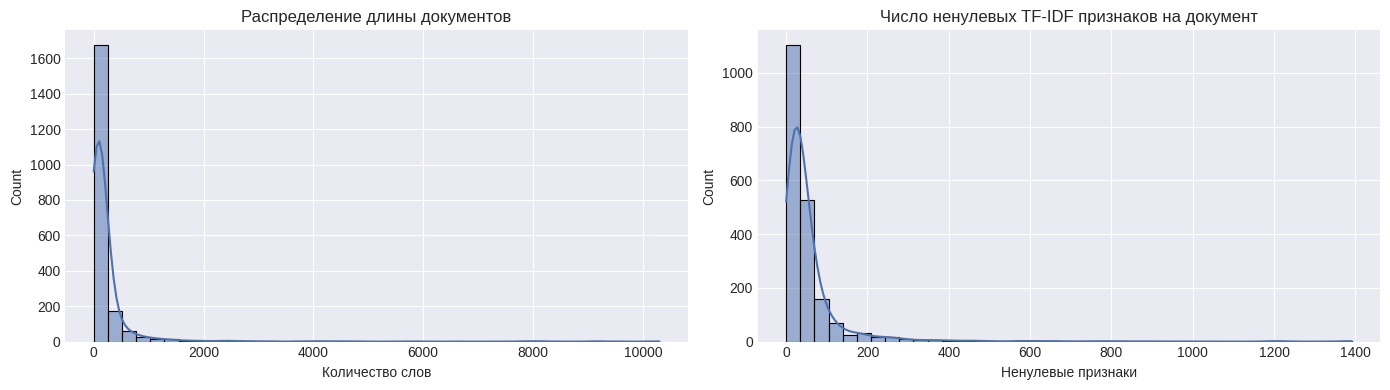

In [40]:
doc_lengths = texts.str.split().str.len()
nonzero_per_doc = np.diff(X_tfidf.tocsr().indptr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(doc_lengths, bins=40, kde=True, ax=axes[0])
axes[0].set_title('Распределение длины документов')
axes[0].set_xlabel('Количество слов')

sns.histplot(nonzero_per_doc, bins=40, kde=True, ax=axes[1])
axes[1].set_title('Число ненулевых TF-IDF признаков на документ')
axes[1].set_xlabel('Ненулевые признаки')
plt.tight_layout()


## 4. Методы понижения размерности

Сравниваем три метода снижения размерности:
*   TruncatedSVD
*   NMF
*   UMAP

Везде сжимаем до 20 компонент для кластеризации, а для картинок до 2D.


In [41]:
N_COMPONENTS = 20
N_CLUSTERS = len(np.unique(y))
RANDOM_STATE = 42


def make_representations(X):
    reducers = {
        'TruncatedSVD': TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE),
        'NMF': NMF(n_components=N_COMPONENTS, init='nndsvda', random_state=RANDOM_STATE, max_iter=400),
        'UMAP': umap.UMAP(
            n_components=N_COMPONENTS,
            n_neighbors=30,
            min_dist=0.0,
            metric='cosine',
            random_state=RANDOM_STATE,
        ),
    }

    embeddings = {}
    for name, reducer in reducers.items():
        emb = reducer.fit_transform(X)
        if name != 'NMF':
            emb = normalize(emb)
        embeddings[name] = emb
        print(name, emb.shape)
    return reducers, embeddings

reducers, embeddings = make_representations(X_tfidf)


TruncatedSVD (2000, 20)
NMF (2000, 20)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (2000, 20)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


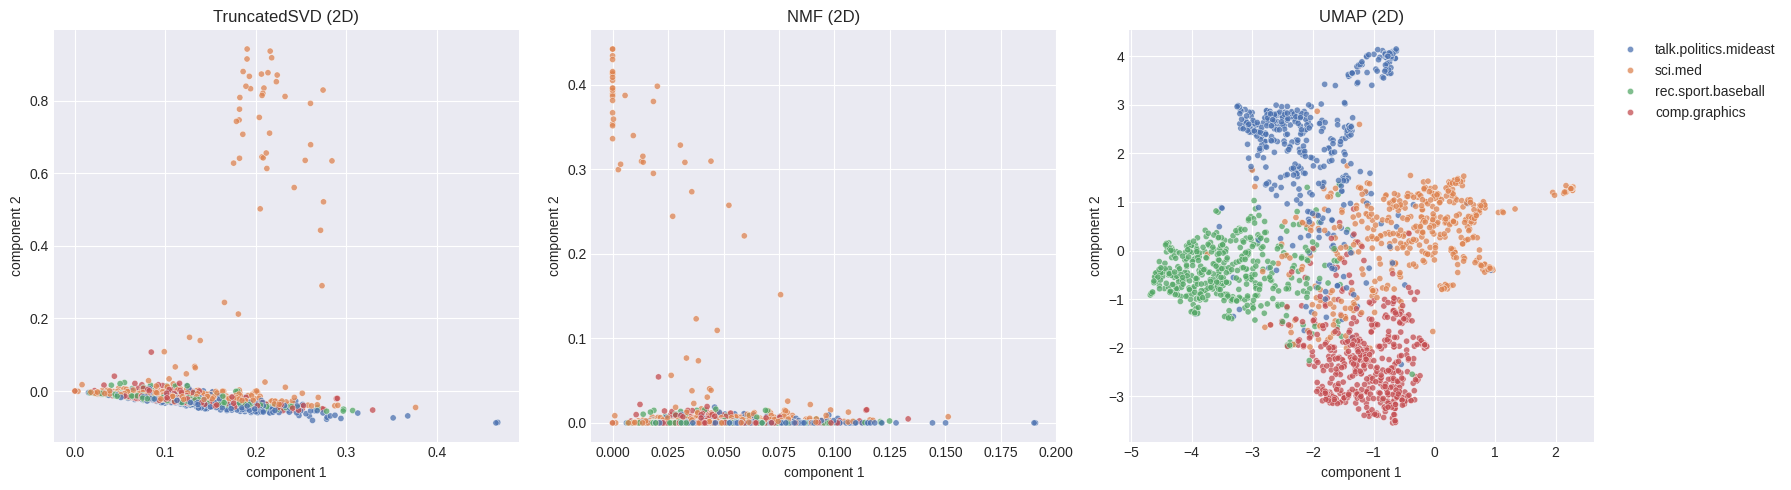

In [42]:
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(X_tfidf)
umap_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.0, metric='cosine', random_state=RANDOM_STATE).fit_transform(X_tfidf)
nmf_2d = NMF(n_components=2, init='nndsvda', random_state=RANDOM_STATE, max_iter=400).fit_transform(X_tfidf)

projections = {
    'TruncatedSVD (2D)': svd_2d,
    'NMF (2D)': nmf_2d,
    'UMAP (2D)': umap_2d,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, proj) in zip(axes, projections.items()):
    sns.scatterplot(
        x=proj[:, 0], y=proj[:, 1], hue=label_names[y], s=20, alpha=0.75, ax=ax, legend=ax is axes[2]
    )
    ax.set_title(title)
    ax.set_xlabel('component 1')
    ax.set_ylabel('component 2')
if axes[2].legend_:
    axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


In [43]:
clusterers = {
    'KMeans': lambda: KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE),
    'Agglomerative': lambda: AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward'),
    'Spectral': lambda: SpectralClustering(
        n_clusters=N_CLUSTERS,
        affinity='nearest_neighbors',
        n_neighbors=15,
        assign_labels='kmeans',
        random_state=RANDOM_STATE,
    ),
}


def evaluate_clustering(X_emb, labels_pred, labels_true):
    return {
        'ARI': adjusted_rand_score(labels_true, labels_pred),
        'NMI': normalized_mutual_info_score(labels_true, labels_pred),
        'Silhouette': silhouette_score(X_emb, labels_pred),
        'Calinski-Harabasz': calinski_harabasz_score(X_emb, labels_pred),
        'Davies-Bouldin': davies_bouldin_score(X_emb, labels_pred),
    }


rows = []
predictions = {}
for dr_name, X_emb in embeddings.items():
    for cl_name, cl_factory in clusterers.items():
        model = cl_factory()
        pred = model.fit_predict(X_emb)
        predictions[(dr_name, cl_name)] = pred
        metrics = evaluate_clustering(X_emb, pred, y)
        rows.append({'DR': dr_name, 'Clustering': cl_name, **metrics})

results = pd.DataFrame(rows).sort_values(['ARI', 'NMI', 'Silhouette'], ascending=[False, False, False])
results


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,DR,Clustering,ARI,NMI,Silhouette,Calinski-Harabasz,Davies-Bouldin
6,UMAP,KMeans,0.723222,0.687896,0.537560,2302.099121,0.719776
7,UMAP,Agglomerative,0.668029,0.664228,0.514400,2011.949463,0.760781
0,TruncatedSVD,KMeans,0.634886,0.632877,0.137321,192.721247,2.456686
1,TruncatedSVD,Agglomerative,0.424563,0.461568,0.097143,157.155009,2.657584
8,UMAP,Spectral,0.253518,0.420530,0.285512,547.223633,0.763573
3,NMF,KMeans,0.177060,0.314358,0.178733,232.928853,1.727160
2,TruncatedSVD,Spectral,0.141102,0.344483,0.111281,102.792352,1.785333
4,NMF,Agglomerative,0.081552,0.275171,0.192207,227.915748,1.423751
5,NMF,Spectral,0.008840,0.116272,0.396166,225.480921,0.700503


## 5. Методы кластеризации

Сравниваем три алгоритма:
- KMeans
- Agglomerative Clustering
- Spectral Clustering

Так составим центроидный, иерархический и графовый подходы.


In [44]:
ranked = results.copy()
ranked['DB_inverted'] = -ranked['Davies-Bouldin']
score_cols = ['ARI', 'NMI', 'Silhouette', 'Calinski-Harabasz', 'DB_inverted']
for col in score_cols:
    ranked[f'rank_{col}'] = ranked[col].rank(ascending=False, method='average')
ranked['mean_rank'] = ranked[[f'rank_{c}' for c in score_cols]].mean(axis=1)
ranked = ranked.sort_values('mean_rank')
ranked[['DR', 'Clustering', 'mean_rank'] + score_cols]


,DR,Clustering,mean_rank,ARI,NMI,Silhouette,Calinski-Harabasz,DB_inverted
6,UMAP,KMeans,1.2,0.723222,0.687896,0.537560,2302.099121,-0.719776
7,UMAP,Agglomerative,2.2,0.668029,0.664228,0.514400,2011.949463,-0.760781
8,UMAP,Spectral,4.2,0.253518,0.420530,0.285512,547.223633,-0.763573
0,TruncatedSVD,KMeans,5.6,0.634886,0.632877,0.137321,192.721247,-2.456686
5,NMF,Spectral,5.6,0.008840,0.116272,0.396166,225.480921,-0.700503
3,NMF,KMeans,5.8,0.177060,0.314358,0.178733,232.928853,-1.727160
4,NMF,Agglomerative,6.2,0.081552,0.275171,0.192207,227.915748,-1.423751
1,TruncatedSVD,Agglomerative,6.8,0.424563,0.461568,0.097143,157.155009,-2.657584
2,TruncatedSVD,Spectral,7.4,0.141102,0.344483,0.111281,102.792352,-1.785333


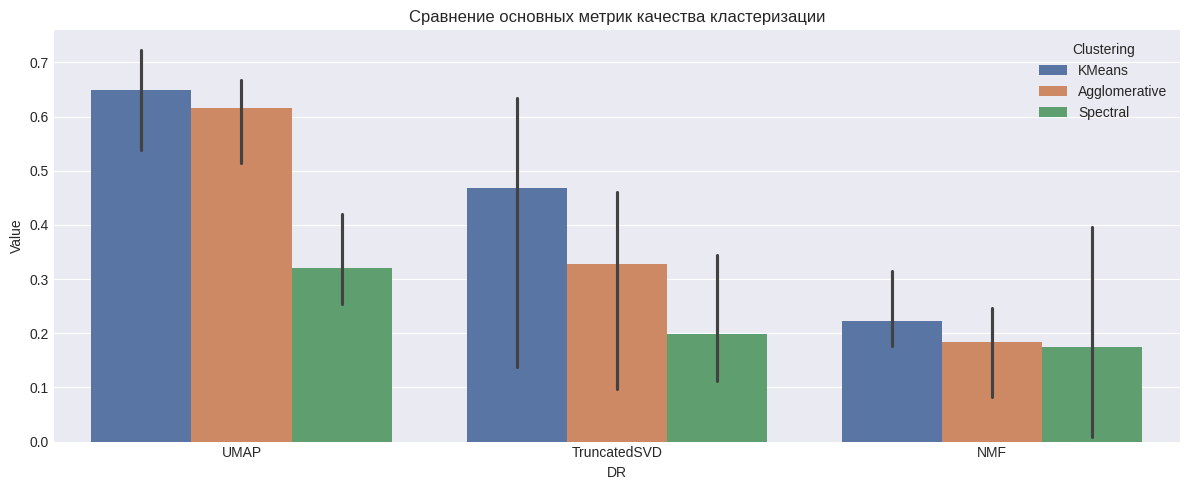

In [45]:
plt.figure(figsize=(12, 5))
plot_df = results.melt(id_vars=['DR', 'Clustering'], value_vars=['ARI', 'NMI', 'Silhouette'],
                       var_name='Metric', value_name='Value')
sns.barplot(data=plot_df, x='DR', y='Value', hue='Clustering')
plt.title('Сравнение основных метрик качества кластеризации')
plt.tight_layout()


## 6. Анализ устойчивости кластеризации

Устойчивость оцениваем так:
1. Для нескольких лучших пайплайнов запускаем несколько повторов на стратифицированных подвыборках.
2. Сравниваем разметки кластеров между повторами по Adjusted Rand Index на пересечении объектов.
3. Дополнительно измеряем разброс качественных метрик между повторами.


In [46]:
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_STATE)


def build_reducer(name, seed):
    if name == 'TruncatedSVD':
        return TruncatedSVD(n_components=N_COMPONENTS, random_state=seed)
    if name == 'NMF':
        return NMF(n_components=N_COMPONENTS, init='nndsvda', random_state=seed, max_iter=400)
    if name == 'UMAP':
        return umap.UMAP(n_components=N_COMPONENTS, n_neighbors=30, min_dist=0.0, metric='cosine', random_state=seed)
    raise ValueError(name)


def build_clusterer(name, seed):
    if name == 'KMeans':
        return KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=seed)
    if name == 'Agglomerative':
        return AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
    if name == 'Spectral':
        return SpectralClustering(
            n_clusters=N_CLUSTERS,
            affinity='nearest_neighbors',
            n_neighbors=15,
            assign_labels='kmeans',
            random_state=seed,
        )
    raise ValueError(name)


def stability_for_pipeline(dr_name, cl_name):
    split_predictions = []
    split_metrics = []

    for split_id, (train_idx, _) in enumerate(sss.split(X_tfidf, y)):
        X_sub = X_tfidf[train_idx]
        y_sub = y[train_idx]
        seed = RANDOM_STATE + split_id

        reducer = build_reducer(dr_name, seed)
        X_emb = reducer.fit_transform(X_sub)
        if dr_name != 'NMF':
            X_emb = normalize(X_emb)

        clusterer = build_clusterer(cl_name, seed)
        pred = clusterer.fit_predict(X_emb)
        split_predictions.append((train_idx, pred))
        split_metrics.append(evaluate_clustering(X_emb, pred, y_sub))

    pair_ari = []
    for i in range(len(split_predictions)):
        idx_i, pred_i = split_predictions[i]
        map_i = dict(zip(idx_i, pred_i))
        for j in range(i + 1, len(split_predictions)):
            idx_j, pred_j = split_predictions[j]
            map_j = dict(zip(idx_j, pred_j))
            overlap = np.intersect1d(idx_i, idx_j)
            labels_i = [map_i[k] for k in overlap]
            labels_j = [map_j[k] for k in overlap]
            pair_ari.append(adjusted_rand_score(labels_i, labels_j))

    metrics_df = pd.DataFrame(split_metrics)
    return {
        'stability_ari_mean': float(np.mean(pair_ari)),
        'stability_ari_std': float(np.std(pair_ari)),
        'quality_std_mean': float(metrics_df[['ARI', 'NMI', 'Silhouette']].std().mean()),
    }

stability_rows = []
for _, row in ranked[['DR', 'Clustering']].head(5).iterrows():
    stab = stability_for_pipeline(row['DR'], row['Clustering'])
    stability_rows.append({'DR': row['DR'], 'Clustering': row['Clustering'], **stab})

stability_df = pd.DataFrame(stability_rows).sort_values(['stability_ari_mean', 'quality_std_mean'], ascending=[False, True])
stability_df


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

,DR,Clustering,stability_ari_mean,stability_ari_std,quality_std_mean
3,TruncatedSVD,KMeans,0.890704,0.041099,0.008243
0,UMAP,KMeans,0.836084,0.014940,0.010251
1,UMAP,Agglomerative,0.748743,0.042181,0.015677
4,NMF,Spectral,0.423419,0.249227,0.082135
2,UMAP,Spectral,0.421672,0.239029,0.104043


In [47]:
summary = ranked.merge(stability_df, on=['DR', 'Clustering'])
summary = summary.sort_values(['mean_rank', 'stability_ari_mean'], ascending=[True, False])
summary[['DR', 'Clustering', 'mean_rank', 'ARI', 'NMI', 'Silhouette', 'stability_ari_mean', 'quality_std_mean']]


,DR,Clustering,mean_rank,ARI,NMI,Silhouette,stability_ari_mean,quality_std_mean
0,UMAP,KMeans,1.2,0.723222,0.687896,0.537560,0.836084,0.010251
1,UMAP,Agglomerative,2.2,0.668029,0.664228,0.514400,0.748743,0.015677
2,UMAP,Spectral,4.2,0.253518,0.420530,0.285512,0.421672,0.104043
3,TruncatedSVD,KMeans,5.6,0.634886,0.632877,0.137321,0.890704,0.008243
4,NMF,Spectral,5.6,0.008840,0.116272,0.396166,0.423419,0.082135


## 7. Выбор лучшего пайплайна

Выберем пайплайн, который одновременно:
- показывает высокое качество по внешним и внутренним метрикам
- не теряет устойчивость на подвыборках
- остаётся интерпретируемым


In [48]:
best_dr = summary.iloc[0]['DR']
best_cl = summary.iloc[0]['Clustering']
print('Лучший пайплайн:', best_dr, '→', best_cl)

best_labels = predictions[(best_dr, best_cl)]


Лучший пайплайн: UMAP → KMeans


## 8. Интерпретация кластеров

Для текстового датасета интерпретация особенно важна.
Смотрим:
1. какие реальные темы доминируют в каждом кластере
2. какие слова имеют наибольший средний TF-IDF внутри кластера


In [49]:
cluster_vs_class = pd.crosstab(
    pd.Series(best_labels, name='cluster'),
    pd.Series(label_names[y], name='true_class'),
    normalize='index'
)
cluster_vs_class


true_class,comp.graphics,rec.sport.baseball,sci.med,talk.politics.mideast
cluster,,,,
0,0.805601,0.047776,0.105437,0.041186
1,0.023207,0.012658,0.894515,0.069620
2,0.009940,0.912525,0.039761,0.037773
3,0.002404,0.004808,0.019231,0.973558


In [50]:
def top_terms_per_cluster(X_sparse, cluster_labels, terms, top_n=12):
    rows = []
    for cluster_id in np.unique(cluster_labels):
        cluster_mask = cluster_labels == cluster_id
        centroid = np.asarray(X_sparse[cluster_mask].mean(axis=0)).ravel()
        top_idx = np.argsort(centroid)[::-1][:top_n]
        rows.append({
            'cluster': cluster_id,
            'top_terms': ', '.join(terms[top_idx])
        })
    return pd.DataFrame(rows)

interpret_df = top_terms_per_cluster(X_tfidf, best_labels, feature_names, top_n=12)
interpret_df


,cluster,top_terms
0,0,"graphics, thanks, know, image, program, mail, ..."
1,1,"don, msg, doctor, like, know, people, cause, m..."
2,2,"game, year, games, think, team, baseball, play..."
3,3,"israel, people, jews, israeli, armenian, jewis..."


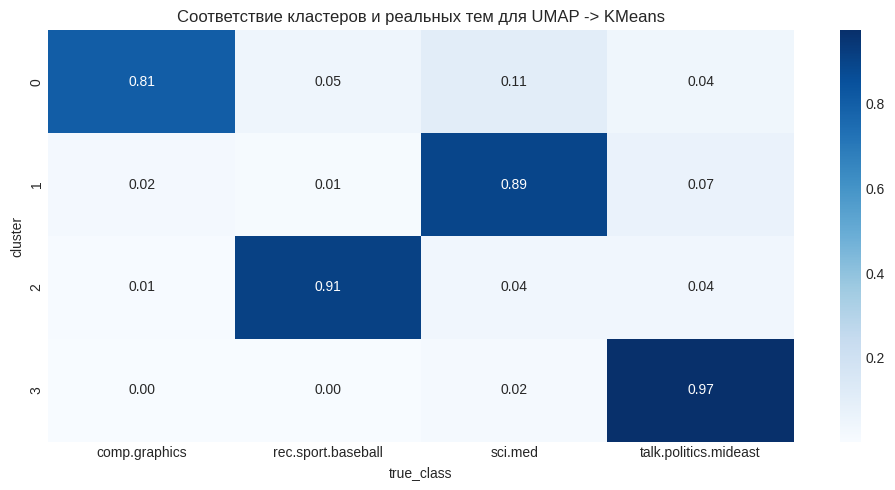

In [51]:
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_vs_class, annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Соответствие кластеров и реальных тем для {best_dr} -> {best_cl}')
plt.tight_layout()


## 9. Дополнительный анализ: согласованность метрик качества и устойчивости


In [52]:
metric_cols = ['ARI', 'NMI', 'Silhouette', 'stability_ari_mean']
corr = summary[metric_cols].corr(method='spearman')
corr


,ARI,NMI,Silhouette,stability_ari_mean
ARI,1.0,1.0,0.6,0.6
NMI,1.0,1.0,0.6,0.6
Silhouette,0.6,0.6,1.0,0.0
stability_ari_mean,0.6,0.6,0.0,1.0


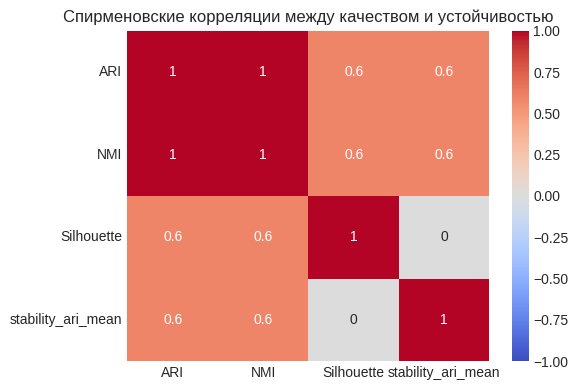

In [53]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Спирменовские корреляции между качеством и устойчивостью')
plt.tight_layout()


## 10. Выводы

1. TruncatedSVD / NMF / UMAP покрывают три важных семейства методов DR: линейные, факторизационные и нелинейные подходы.
2. KMeans / Agglomerative / Spectral позволяют сравнить разные принципы кластеризации.

### Практические выводы
- Если важна интерпретируемость - хороши NMF и TruncatedSVD.
- Если важна визуальная разделимость и локальная структура - подходит UMAP.
- Если нужна устойчивость и простота - сильным решением является TruncatedSVD + KMeans.
- Для прикладной аналитики кластеров недостаточно одной метрики, нужно одновременно учитывать несколько:внешнее качество, внутреннюю компактность, устойчивость и содержательную интерпретацию.

### Итог
Проект показал, что задача кластеризации высокоразмерных реальных данных должна решаться не одним алгоритмом, а через сравнение нескольких пайплайнов DR -> clustering с последующей проверкой устойчивости и интерпретации результатов.
